In [1]:
import argparse
import time
import numpy as np
import matplotlib.pyplot as plt


from arguments import add_arguments
from ilqr.multiLQR import iLQR
from visualize import draw_car

In [2]:
def timer_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        epochs = kwargs.get('epochs', 'unknown number of')
        print(f"Running {func.__name__} for {epochs} epochs took {end_time - start_time} seconds.")
        print(f"The average time for each epoch is {(end_time - start_time)/epochs} seconds.")
        return result
    return wrapper

class SimParams:    
    agent1_start_state = np.array([5, -5, 0, 0])
    agent2_start_state = np.array([50, -40, 0, np.pi/2])
    agent3_start_state = np.array([40, 45, 0, -np.pi/2])



In [3]:
def create_global_plan_1():
    x1 = np.arange(5, 50)  
    y1 = np.full_like(x1, -5) 

    y2 = np.arange(-5, 45)  
    x2 = np.full_like(y2, 50)  

    x_coords = np.concatenate((x1, x2))
    y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    return points

def create_global_plan_2():
    y1 = np.arange(-40, 5)
    x1 = np.full_like(y1, 50) 

    x2 = np.arange(50, -1, -1)
    y2 = np.full_like(x2, 5)

    x_coords = np.concatenate((x1, x2))
    y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    return points

def create_global_plan_3():
    y1 = np.arange(45, -5, -1)
    x1 = np.full_like(y1, 40) 

    x2 = np.arange(40, 90)
    y2 = np.full_like(x2, -5)

    x_coords = np.concatenate((x1, x2))
    y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    return points

In [4]:
class multiAgentSimulator:
    def __init__(self, args, SimParams):
        self.args = args

        self.simparams = SimParams
        self.navigation_agent1 = None
        self.navigation_agent2 = None
        self.navigation_agent3 = None
        
        self.nominal_control = np.zeros((2, self.args.horizon))
        self.nominal_control[0,:] = np.linspace(self.args.acc_control_limits[1], 0, self.args.horizon)
        
        self.count = 0
        
        self.current_agent1_state = self.simparams.agent1_start_state
        self.current_agent2_state = self.simparams.agent2_start_state
        self.current_agent3_state = self.simparams.agent3_start_state
        
        self.last_agent1_states = np.expand_dims(self.simulate_states(
            self.current_agent1_state, self.nominal_control), axis=0)
        self.last_agent2_states = np.expand_dims(self.simulate_states(
            self.current_agent2_state, self.nominal_control), axis=0)
        self.last_agent3_states = np.expand_dims(self.simulate_states(
            self.current_agent3_state, self.nominal_control), axis=0)
        
        self.agent1_states = [self.current_agent1_state]
        self.agent2_states = [self.current_agent2_state]
        self.agent3_states = [self.current_agent3_state]
        self.agent1_controls = []
        self.agent2_controls = []
        self.agent3_controls = []
        # self.global_plan_agent1_cross = self.create_global_plan(25, 70, -5)
        self.global_plan_agent1_cross = create_global_plan_1()
        self.global_plan_agent2_cross = create_global_plan_2()
        self.global_plan_agent3_cross = create_global_plan_3()
        

        self.create_ilqr_agents(self.args.sim_options)        

    
    def reset(self):
        self.create_ilqr_agents(self.args.sim_options)        
        self.current_agent1_state = self.simparams.agent1_start_state
        self.current_agent2_state = self.simparams.agent2_start_state
        self.current_agent3_state = self.simparams.agent3_start_state

        self.agent1_states = [self.current_agent1_state]
        self.agent2_states = [self.current_agent2_state]
        self.agent3_states = [self.current_agent3_state]

        self.count = 0
        
    def create_ilqr_agents(self, simu_options):
        global_plan_agent1 = None; global_plan_agent2 = None
        if simu_options == 'cross':
            global_plan_agent1 = self.global_plan_agent1_cross
            global_plan_agent2 = self.global_plan_agent2_cross
            if self.args.number_of_agents == 3:
                global_plan_agent3 = self.global_plan_agent3_cross
                
        self.navigation_agent1 = iLQR(self.args, self.args.car_dims, "1")
        self.navigation_agent1.set_global_plan(global_plan_agent1)
        
        self.navigation_agent2 = iLQR(self.args, self.args.car_dims, "2")
        self.navigation_agent2.set_global_plan(global_plan_agent2)
        
        if self.args.number_of_agents == 3:
            self.navigation_agent3 = iLQR(self.args, self.args.car_dims, "3")
            self.navigation_agent3.set_global_plan(global_plan_agent3)
        
    def get_agent1_states(self):
        agent1_states = np.array([self.current_agent1_state[0], self.current_agent1_state[1], 
                               self.current_agent1_state[2], self.current_agent1_state[3]])
        return agent1_states
    
    def get_agent2_states(self):
        agent2_states = np.array([self.current_agent2_state[0], self.current_agent2_state[1], 
                               self.current_agent2_state[2], self.current_agent2_state[3]])
        return agent2_states

    def get_agent3_states(self):
        agent3_states = np.array([self.current_agent3_state[0], self.current_agent3_state[1], 
                               self.current_agent3_state[2], self.current_agent3_state[3]])
        return agent3_states
    
    def get_npc_states(self, i):
        return self.NPC_states[:, i:i+self.args.horizon]
    
    def create_global_plan(self, desired_start_x, desired_end_x, desired_y):
        plan_ilqr = []
        for i in range(desired_start_x, desired_end_x):
            plan_ilqr.append(np.array([i, desired_y]))
        plan_ilqr = np.array(plan_ilqr)
        return plan_ilqr
        
    def run_model_simulation(self, state, control):
        """
        Find the next state of the vehicle given the current state and control input
        """
        # Clips the controller values between min and max accel and steer values
        control[0] = np.clip(control[0], self.args.acc_control_limits[0], self.args.acc_control_limits[1])
        control[1] = np.clip(control[1], state[2]*np.tan(self.args.steering_control_limits[0])/self.args.wheelbase, state[2]*np.tan(self.args.steering_control_limits[1])/self.args.wheelbase)
        
        Ts = self.args.timestep
        # print(state[2] + control[0]*Ts)
        next_state = np.array([state[0] + np.cos(state[3])*(state[2]*Ts + (control[0]*Ts**2)/2),
                               state[1] + np.sin(state[3])*(state[2]*Ts + (control[0]*Ts**2)/2),
                               np.clip(state[2] + control[0]*Ts, 0.0, self.args.max_speed),
                              (state[3] + control[1]*Ts)%(2*np.pi)])

        return next_state
    
    def simulate_states(self, init_state, controls):
        states_list = []
        states_list.append(init_state)
        controls = np.hstack((controls, np.zeros((2, self.args.horizon))))
        for i in range(controls.shape[1]):
            next_state = self.run_model_simulation(states_list[i], controls[:, i])
            states_list.append(next_state)
        states_list = np.array(states_list).T
        return states_list
    
    def run_step_ilqr_no_br(self):
        assert self.navigation_agent1 != None, "Navigation Agent not initialized"
        # print('step', self.count, self.last_agent2_states.shape)
        lane = np.zeros_like(self.last_agent1_states)
        lane[:,1,:] = -14
        lane[:,0,:] = np.arange(lane.shape[2]) + self.last_agent1_states[0,0,0]
        # print(lane)
        print(self.last_agent2_states.shape)
        print(lane.shape)
        print("---")
        # generate the npcs for agent1
        if self.args.number_of_agents == 3:
            npcs_for_agent1 = np.array([self.last_agent2_states, self.last_agent3_states, lane])
        else:
            npcs_for_agent1 = np.array([self.last_agent2_states, lane])
        print(npcs_for_agent1.shape)
        states_agent1_hori, controls_agent1, cost_agent1 = self.navigation_agent1.run_step(self.get_agent1_states(), npcs_for_agent1)
        self.current_agent1_state = self.run_model_simulation(self.current_agent1_state, controls_agent1[:, 0])
        self.agent1_states.append(self.current_agent1_state)
        
        # generate the npcs for agent2
        if self.args.number_of_agents == 3:
            npcs_for_agent2 = np.array([self.last_agent1_states, self.last_agent3_states])
        else:
            npcs_for_agent2 = np.array([self.last_agent1_states])
        states_agent2_hori, controls_agent2, cost_agent2 = self.navigation_agent2.run_step(self.get_agent2_states(), npcs_for_agent2)
        self.current_agent2_state = self.run_model_simulation(self.current_agent2_state, controls_agent2[:, 0])
        self.agent2_states.append(self.current_agent2_state)

        # generate the npcs for agent3
        if self.args.number_of_agents == 3:
            npcs_for_agent3 = np.array([self.last_agent1_states, self.last_agent2_states])
            states_agent3_hori, controls_agent3, cost_agent3 = self.navigation_agent3.run_step(self.get_agent3_states(), npcs_for_agent3)
            self.current_agent3_state = self.run_model_simulation(self.current_agent3_state, controls_agent3[:, 0])
            self.agent3_states.append(self.current_agent3_state)
        
        self.last_agent1_states = np.expand_dims(states_agent1_hori, axis=0)
        self.last_agent2_states = np.expand_dims(states_agent2_hori, axis=0)
        if self.args.number_of_agents == 3:
            self.last_agent3_states = np.expand_dims(states_agent3_hori, axis=0)

        self.count += 1

    def run_step_ilqr_with_br(self):
        assert self.navigation_agent1 != None, "Navigation Agent not initialized"
        # print('step', self.count, self.last_agent2_states.shape)
        # print(lane)
        curr_costs = np.zeros(self.args.number_of_agents)
        last_costs = np.zeros(self.args.number_of_agents)
        loop_count = 0
        current_agent1_state = self.current_agent1_state
        current_agent2_state = self.current_agent2_state
        if self.args.number_of_agents == 3:
            current_agent3_state = self.current_agent3_state
        while True:
            lane = np.zeros_like(self.last_agent1_states)
            lane[:,1,:] = -14
            lane[:,0,:] = np.arange(lane.shape[2]) + self.last_agent1_states[0,0,0]
            # print(self.last_agent2_states.shape)
            # print(lane.shape)
            # print("---")

            # generate the npcs for agent1
            if self.args.number_of_agents == 3:
                npcs_for_agent1 = np.array([self.last_agent2_states, self.last_agent3_states, lane])
            else:
                npcs_for_agent1 = np.array([self.last_agent2_states, lane])
            states_agent1_hori, controls_agent1, curr_cost_agent1 = self.navigation_agent1.run_step(self.get_agent1_states(), npcs_for_agent1)
            current_agent1_state = self.run_model_simulation(self.current_agent1_state, controls_agent1[:, 0])
            # print()

            # generate the npcs for agent2
            if self.args.number_of_agents == 3:
                npcs_for_agent2 = np.array([self.last_agent1_states, self.last_agent3_states])
            else:
                npcs_for_agent2 = np.array([self.last_agent1_states])
            states_agent2_hori, controls_agent2, curr_cost_agent2 = self.navigation_agent2.run_step(self.get_agent2_states(), npcs_for_agent2)
            current_agent2_state = self.run_model_simulation(self.current_agent2_state, controls_agent2[:, 0])

            # generate the npcs for agent3
            if self.args.number_of_agents == 3:
                npcs_for_agent3 = np.array([self.last_agent1_states, self.last_agent2_states])
                states_agent3_hori, controls_agent3, curr_cost_agent3 = self.navigation_agent3.run_step(self.get_agent3_states(), npcs_for_agent3)
                current_agent3_state = self.run_model_simulation(self.current_agent3_state, controls_agent3[:, 0])
            

            curr_costs = np.array([curr_cost_agent1, curr_cost_agent2])
            if self.args.number_of_agents == 3:
                curr_costs = np.array([curr_cost_agent1, curr_cost_agent2, curr_cost_agent3])
            loop_count += 1
            print(loop_count, ':', np.linalg.norm(curr_costs-last_costs, ord=2))#, end='\r')

            if np.linalg.norm(curr_costs-last_costs, ord=2) <= 5 or loop_count >= self.args.loop_tol:
                self.count += 1
                loop_count = 0

                self.current_agent1_state = current_agent1_state
                self.current_agent2_state = current_agent2_state

                self.agent1_states.append(self.current_agent1_state)
                self.agent1_controls.append(controls_agent1[:, 0])
                self.agent2_states.append(self.current_agent2_state)
                self.agent2_controls.append(controls_agent2[:, 0])
                if self.args.number_of_agents == 3:
                    self.current_agent3_state = current_agent3_state
                    self.agent3_states.append(self.current_agent3_state)
                    self.agent3_controls.append(controls_agent3[:, 0])
                break
                
            else:
                last_costs = curr_costs
                self.last_agent1_states = np.expand_dims(states_agent1_hori, axis=0)
                self.last_agent2_states = np.expand_dims(states_agent2_hori, axis=0)
                if self.args.number_of_agents == 3:
                    self.last_agent3_states = np.expand_dims(states_agent3_hori, axis=0)


    @timer_decorator
    def run_epochs_ilqr(self, epochs):
        self.reset()
        for i in range(epochs):
            self.run_step_ilqr_with_br()
            print('\n')
            print('Step:', self.count)
            # print('Step:', self.count)

    def compute_distance(self, agentx_states, agenty_states):
        return np.linalg.norm(np.array(agentx_states)[:,:2]-np.array(agenty_states)[:,:2], 2, axis=1)
    
    def visualize_frame(self, X, Y, YAW, ox = [], oy = []):
        colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k'];
        plt.figure(figsize=(6,6))
        plt.plot(ox, oy, "sk")
        for k in range(len(X[0])):
            plt.cla()
            plt.plot([0, 35], [-10, -10], color='black')
            plt.plot([55, 90], [-10, -10], color='black')
            plt.plot([45, 45], [10, 45], color='#ff9933', linestyle='--')
            plt.plot([0, 35], [10, 10], color='black')
            plt.plot([55, 90], [10, 10], color='black')
            plt.plot([45, 45], [-10, -45], color='#ff9933', linestyle='--')
            plt.plot([35, 35], [-10, -45], color='black')
            plt.plot([55, 55], [-10, -45], color='black')
            plt.plot([0, 35], [0, 0], color='#ff9933', linestyle='--')
            plt.plot([55, 55], [10, 45], color='black')
            plt.plot([35, 35], [10, 45], color='black')
            plt.plot([55, 90], [0, 0], color='#ff9933', linestyle='--')             
            idx_car = 0
            for x, y, yaw in zip(X, Y, YAW):
                plt.plot(x, y, linewidth=1.5, color=colors[idx_car], label='Agent '+str(idx_car+1))
                draw_car(x[-1], y[-1], yaw[-1], 'dimgray')
                draw_car(x[k], y[k], yaw[k], colors[idx_car])
                idx_car += 1
            if self.args.sim_options == 'cross':
                plt.plot(self.global_plan_agent1_cross[::4,0], 
                self.global_plan_agent1_cross[::4,1], 
                'o', color=(1, 0, 0, 0.2), label='Global Plan Agent 1')        
                plt.plot(self.global_plan_agent2_cross[::3,0], 
                self.global_plan_agent2_cross[::3,1], 
                '*', color=(0, 0, 1, 0.2), label='Global Plan Agent 2')  
                if self.args.number_of_agents == 3:
                    plt.plot(self.global_plan_agent3_cross[::3,0], 
                    self.global_plan_agent3_cross[::3,1], 
                    '+', color=(0, 1, 0, 0.5), label='Global Plan Agent 3')  

            plt.legend()
            plt.title("iLQR Solution")
            plt.axis("equal")
            plt.pause(0.1)

        plt.show()
    
    def visualize_all(self, interval):
        if self.args.number_of_agents == 2:
            self.visualize_frame([list(np.array(self.agent1_states)[::interval, 0]), list(np.array(self.agent2_states)[::interval, 0])],
                [list(np.array(self.agent1_states)[::interval, 1]), list(np.array(self.agent2_states)[::interval, 1])], 
                [list(np.array(self.agent1_states)[::interval, 3]), list(np.array(self.agent2_states)[::interval, 3])])
        elif self.args.number_of_agents == 3:
            self.visualize_frame([list(np.array(self.agent1_states)[::interval, 0]), list(np.array(self.agent2_states)[::interval, 0]), list(np.array(self.agent3_states)[::interval, 0])],
                [list(np.array(self.agent1_states)[::interval, 1]), list(np.array(self.agent2_states)[::interval, 1]), list(np.array(self.agent3_states)[::interval, 1])], 
                [list(np.array(self.agent1_states)[::interval, 3]), list(np.array(self.agent2_states)[::interval, 3]), list(np.array(self.agent3_states)[::interval, 3])])

---

1 : 17723.873425825073
2 : 19.15294347524309
3 : 9.290626145078237
4 : 5.642116374206358
5 : 3.1813371792495837


Step: 1
1 : 16620.71723363087
2 : 0.9594952072718328


Step: 2
1 : 15450.48695087281
2 : 0.2249786963481879


Step: 3
1 : 14247.987421734988
2 : 0.30997995594150013


Step: 4
1 : 13030.772521548199
2 : 0.2611524397101271


Step: 5
1 : 11816.910955858277
2 : 0.7259619976790848


Step: 6
1 : 13979.979677467507
2 : 0.6430961521491464


Step: 7
1 : 12568.576629165073
2 : 1.794119418812708


Step: 8
1 : 11207.014240332202
2 : 3.703481050934513


Step: 9
1 : 9913.205075993656
2 : 5.877365037370297
3 : 1.3736319360156273


Step: 10
1 : 8702.548231870764
2 : 4.888637020782906


Step: 11
1 : 10103.384181028192
2 : 0.7151134271773314


Step: 12
1 : 8791.480393637808
2 : 4.407387645984388


Step: 13
1 : 10032.672220618322
2 : 0.5106951468947537


Step: 14
1 : 8655.494122107642
2 : 3.200899078619931


Step: 15
1 : 7402.077049574256
2 : 1.9313935778538052


Step: 16
1 : 8322.12237463435

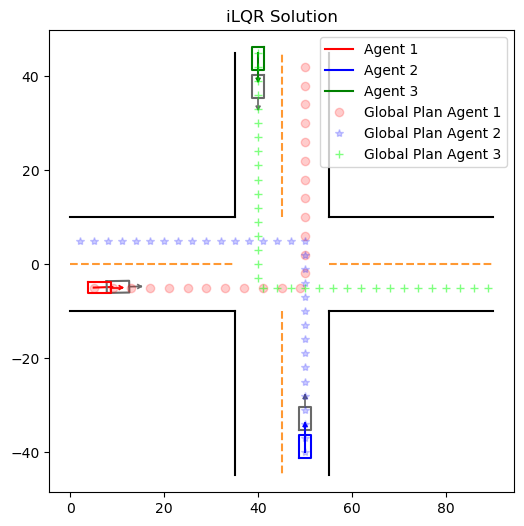

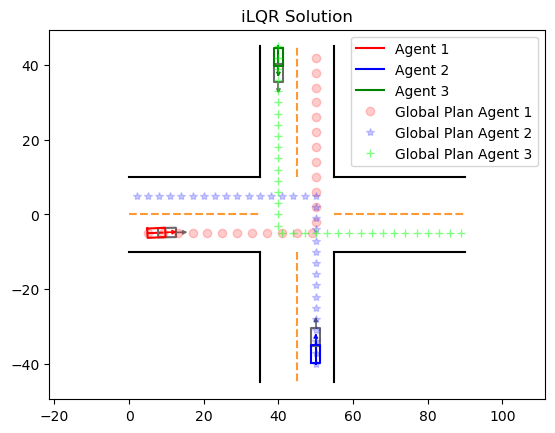

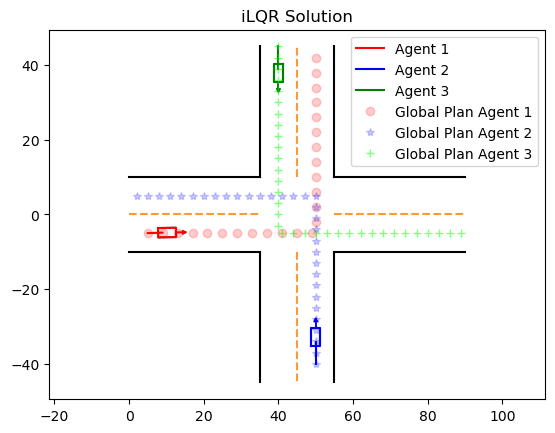

In [5]:
argparser = argparse.ArgumentParser([])
add_arguments(argparser)
argparser.add_argument('--number_of_agents', type=int, default=3, help='Number of agents')
argparser.add_argument('--sim_options', default="cross", type=str, help="Type of simulation, cross")
argparser.add_argument('--epochs', type=int, default=20, help='Total number of epochs for all agents')
argparser.add_argument('--draw_interval', type=int, default=10, help='Interval for drawing the simulation')
argparser.add_argument('--loop_tol', type=int, default=10, help='tolerance of the loop')

args = argparser.parse_args([])

masim = multiAgentSimulator(args, SimParams)
masim.run_epochs_ilqr(epochs=args.epochs)
masim.visualize_all(interval=args.draw_interval)

In [6]:
# masim.visualize_all(1)

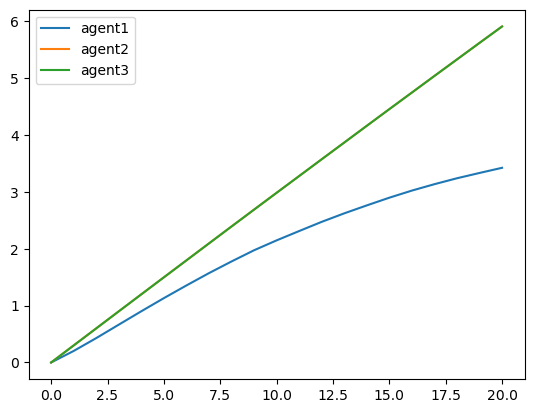

In [7]:
plt.plot(np.array(masim.agent1_states)[:,2], label='agent1')
plt.plot(np.array(masim.agent2_states)[:,2], label='agent2')
plt.plot(np.array(masim.agent3_states)[:,2], label='agent3')
plt.legend()
plt.show()

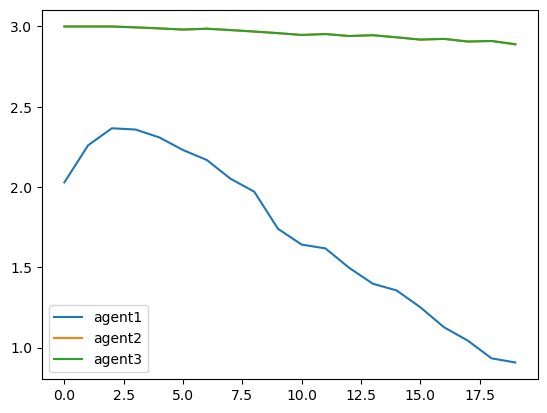

In [8]:
plt.plot(np.array(masim.agent1_controls)[:,0], label='agent1')
plt.plot(np.array(masim.agent2_controls)[:,0], label='agent2')
plt.plot(np.array(masim.agent3_controls)[:,0], label='agent3')
plt.legend()
plt.show()

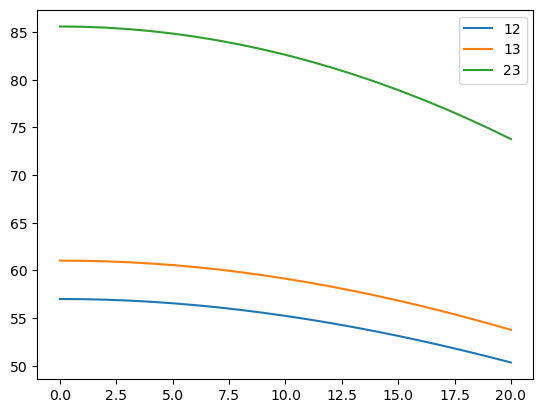

In [9]:
plt.plot(np.linalg.norm(np.array(masim.agent1_states)[:,:2]-np.array(masim.agent2_states)[:,:2], 2, axis=1), label="12")
plt.plot(np.linalg.norm(np.array(masim.agent1_states)[:,:2]-np.array(masim.agent3_states)[:,:2], 2, axis=1), label="13")
plt.plot(np.linalg.norm(np.array(masim.agent3_states)[:,:2]-np.array(masim.agent2_states)[:,:2], 2, axis=1), label="23")
plt.legend()
plt.show()